# U-Net Image Segmentation Demo

This Notebook demonstrates how to use the U-Net model for image segmentation.
We will go through the process of data loading, model training, and evaluation step-by-step.

## 1. Import Libraries and Modules

Import all necessary libraries, including PyTorch, our custom dataset, model, training, and visualization functions.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import random

# Import custom modules
from utils.dataset import SegmentationDataset, get_transforms
from utils.visualization import visualize_segmentation, visualize_random_dataset_sample # Import new functions
from models.unet import UNet
from utils.train_unet import train_model, evaluate_model
from utils.others import visualize_random_sample

# Check for available GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Set Parameters and Paths

Define data paths, image size, batch size, learning rate, and number of training epochs.

In [ ]:
# Data paths
BASE_DIR = 'dataset/opensource'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train/images')
TRAIN_MASK_DIR = os.path.join(BASE_DIR, 'train/masks')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test/images')
TEST_MASK_DIR = os.path.join(BASE_DIR, 'test/masks')

# Hyperparameters
IMG_SIZE = 512  # Adjust image size to fit model and memory
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 5 # Use a small number of epochs for quick demonstration

## 3. Create Datasets and DataLoaders

Use our defined `SegmentationDataset` class to create training and testing datasets, and create `DataLoader` instances for them.

In [3]:
# Get data transforms
transform = get_transforms(IMG_SIZE)

# Create training dataset and loader
train_dataset = SegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=transform)
print(f"Found {len(train_dataset)} training samples.") # Add this line for debugging
if len(train_dataset) > 0:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
else:
    print("Skipping DataLoader creation for empty training dataset.")
    train_loader = None # Or handle appropriately

# Create testing dataset and loader
test_dataset = SegmentationDataset(TEST_IMG_DIR, TEST_MASK_DIR, transform=transform)
print(f"Found {len(test_dataset)} test samples.") # Add this line for debugging
if len(test_dataset) > 0:
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
else:
    print("Skipping DataLoader creation for empty test dataset.")
    test_loader = None # Or handle appropriately

# Original print statements (optional now)
# print(f"Training set size: {len(train_dataset)}")
# print(f"Test set size: {len(test_dataset)}")

Found 2424 training samples.
Found 146 test samples.


### 3.1 Visualize Random Dataset Samples

Let's look at a random sample from the training and test datasets to ensure they loaded correctly.

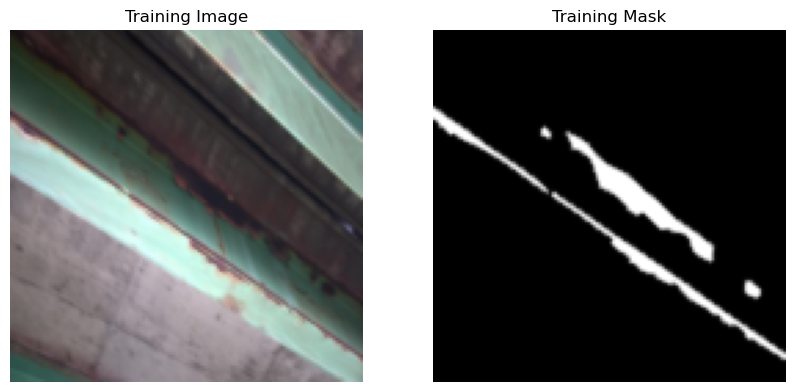

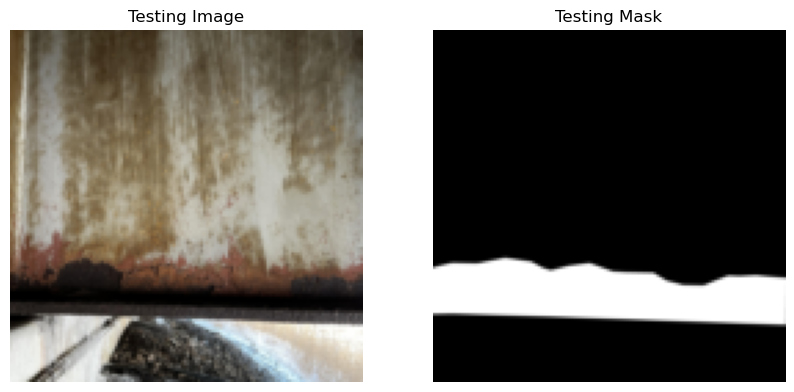

In [4]:
# Call the function to visualize
visualize_random_sample(train_dataset, test_dataset)

## 4. Initialize Model, Loss Function, and Optimizer

Instantiate the U-Net model. Choose an appropriate loss function (e.g., BCEWithLogitsLoss for binary segmentation) and an optimizer (e.g., Adam).

In [5]:
# Initialize model
# n_channels=3 because the input is an RGB image
# n_classes=1 because it's binary segmentation (background vs. damage)
model = UNet(n_channels=3, n_classes=1)
model.to(device)

# Define loss function
# BCEWithLogitsLoss combines Sigmoid layer and BCELoss, more stable
criterion = nn.BCEWithLogitsLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 5. Train the Model

Call the `train_model` function to train the U-Net model.

In [6]:
# Check if train_loader is valid before training
if train_loader:
    trained_model = train_model(model, train_loader, criterion, optimizer, device, num_epochs=NUM_EPOCHS)
else:
    print("Cannot train model: Training data loader is not available.")
    trained_model = model # Keep the initialized model

Epoch 1/5, Loss: 0.4604


Epoch 2/5, Loss: 0.4013


Epoch 3/5, Loss: 0.3816


Epoch 4/5, Loss: 0.3579


Epoch 5/5, Loss: 0.3416
Training finished.


## 6. Evaluate the Model

Use the `evaluate_model` function to evaluate the trained model on the test set. This now includes Loss, Accuracy, and IoU.

In [7]:
# Check if test_loader is valid before evaluation
if test_loader and 'trained_model' in locals(): # Ensure model was trained
    test_loss, test_accuracy, test_iou = evaluate_model(trained_model, test_loader, criterion, device)
    print("\n--- Final Evaluation Metrics ---")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test IoU: {test_iou:.4f}")
elif not test_loader:
    print("Cannot evaluate model: Test data loader is not available.")
else:
    print("Cannot evaluate model: Model training was skipped or failed.")

Test Loss: 0.3307
Test Accuracy: 0.8082
Test IoU (Jaccard): 0.5656

--- Final Evaluation Metrics ---
Test Loss: 0.3307
Test Accuracy: 0.8082
Test IoU: 0.5656


## 7. Visualize Prediction Results

Use the dedicated visualization function to view model predictions, ground truth, and overlays on test samples.

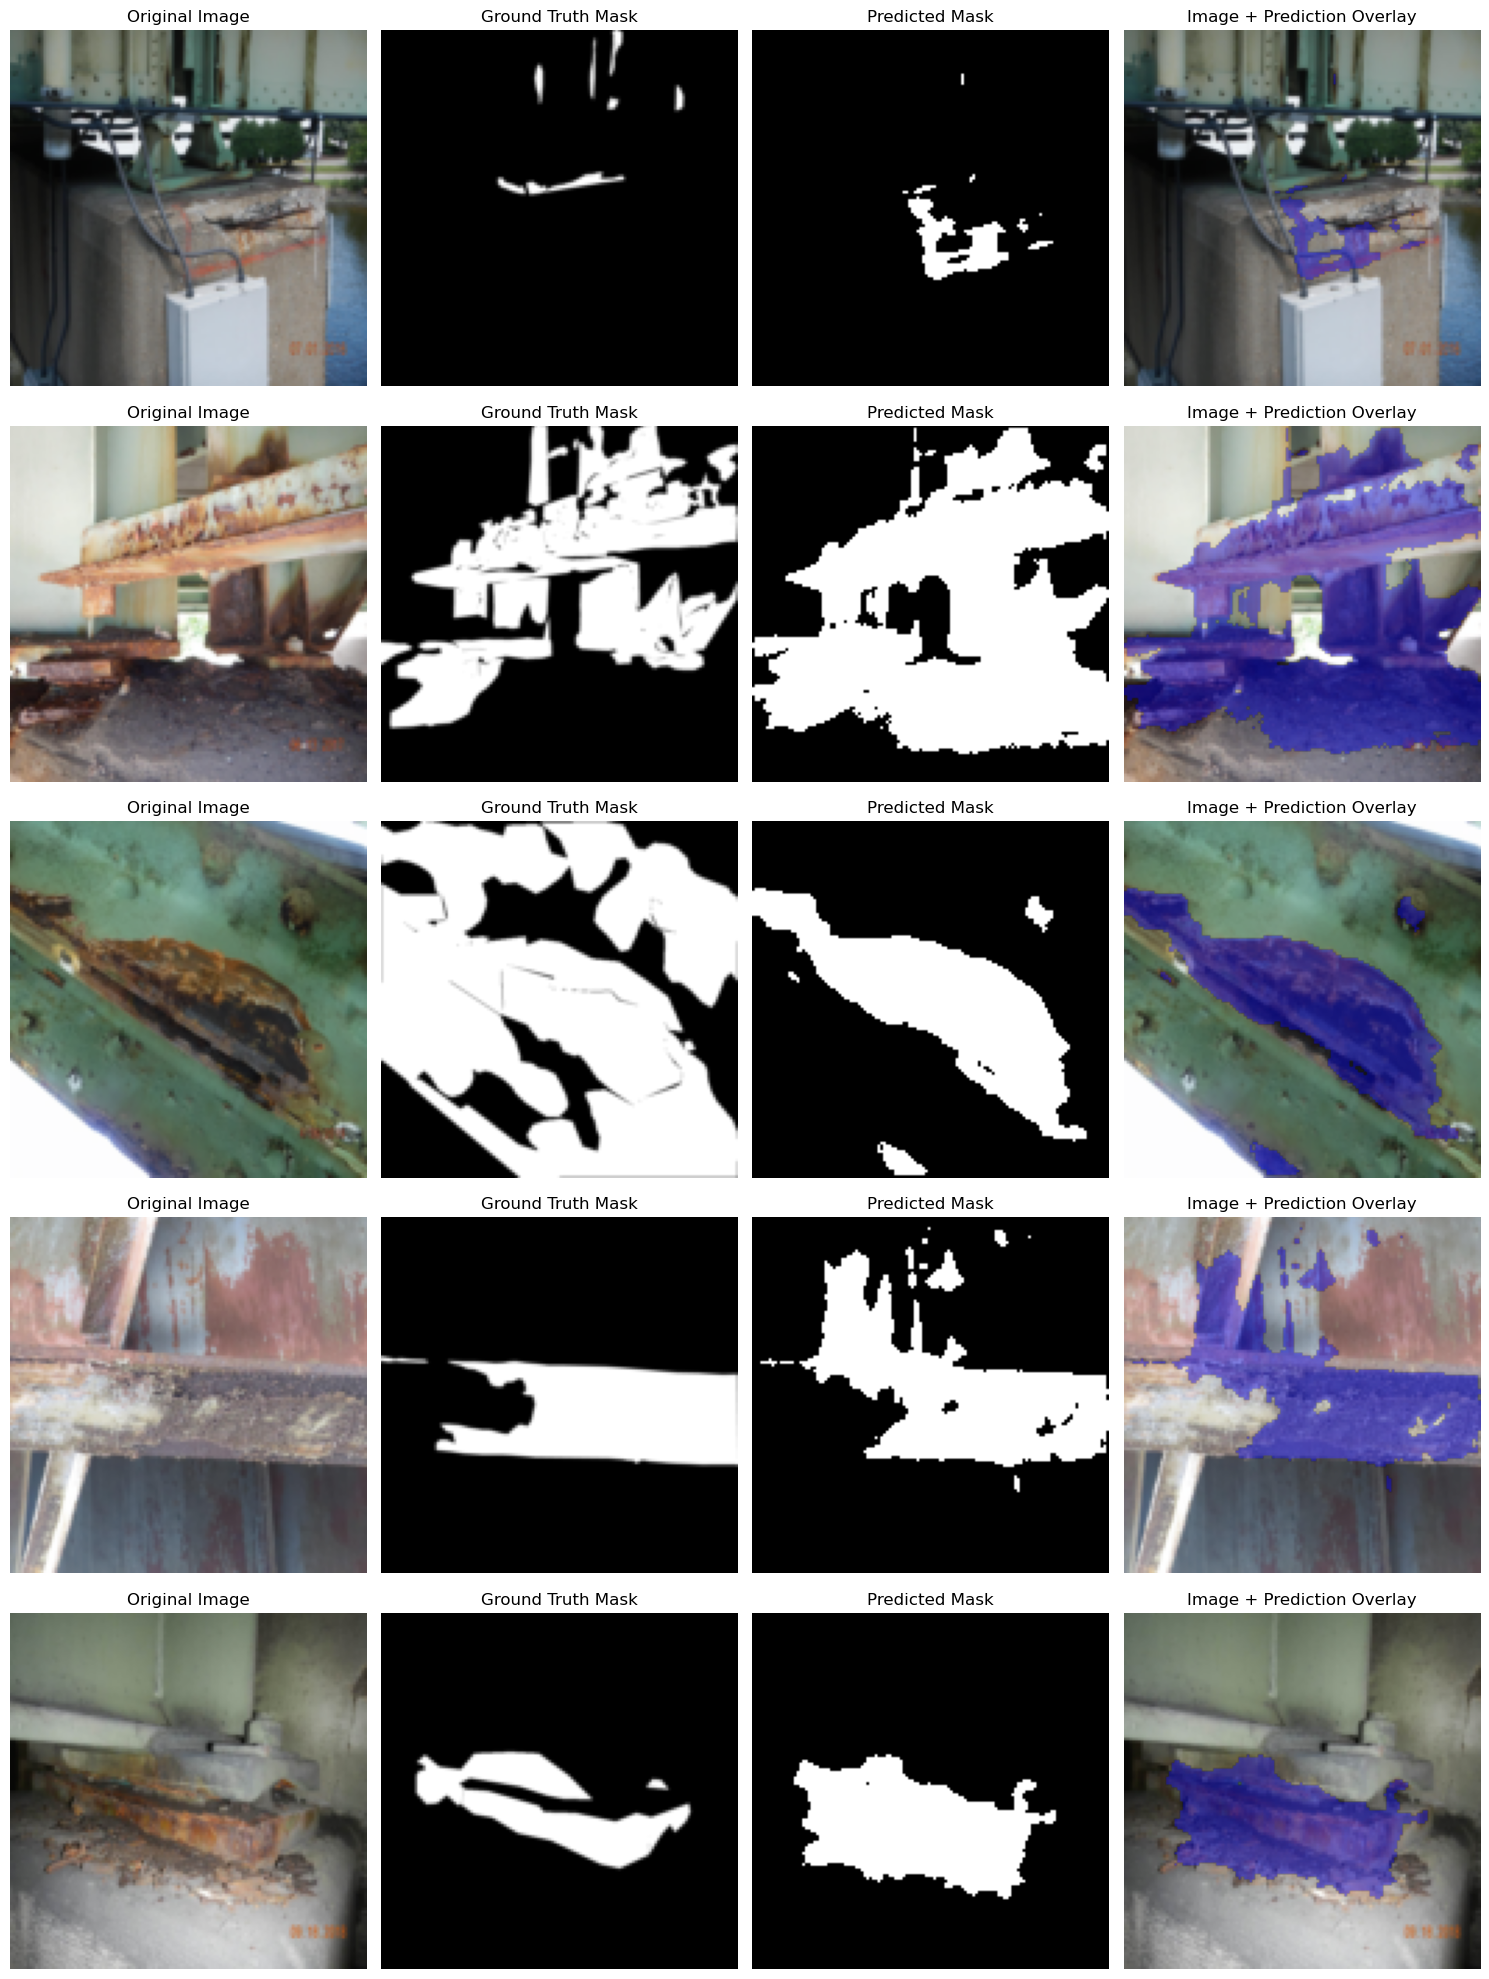

In [8]:

# Visualize some predictions on the test set
visualize_segmentation(trained_model, test_loader, device, num_samples=5)